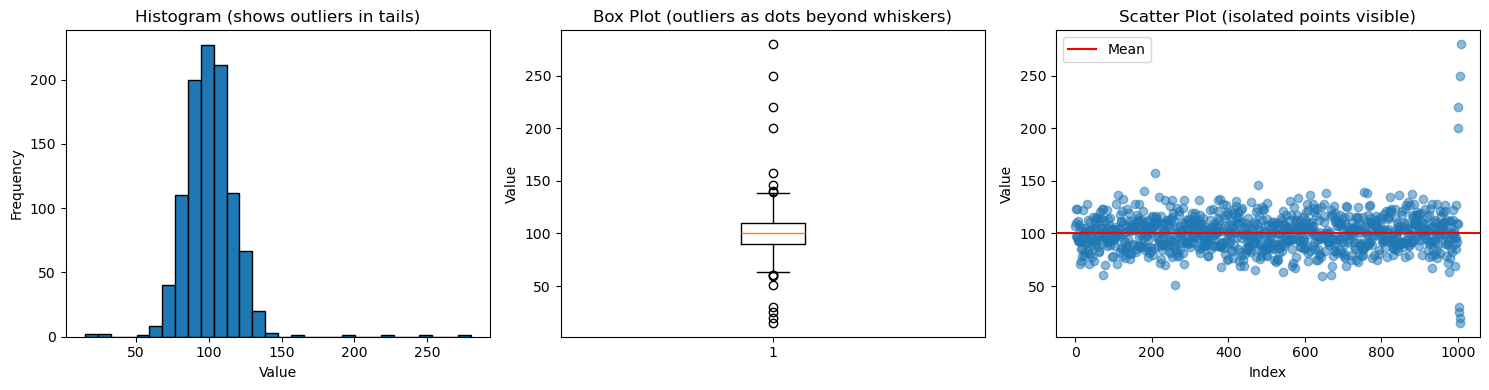

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# Create dataset with outliers
np.random.seed(42)
data_normal = np.random.normal(100, 15, 1000)
# Add some outliers
outliers = [200, 220, 30, 25, 250, 20, 15, 280]
data_with_outliers = np.concatenate([data_normal, outliers])
df_outliers = pd.DataFrame({'value': data_with_outliers})
# Visualize outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# Histogram
axes[0].hist(df_outliers['value'], bins=30, edgecolor='black')
axes[0].set_title('Histogram (shows outliers in tails)')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')
# Box plot
axes[1].boxplot(df_outliers['value'])
axes[1].set_title('Box Plot (outliers as dots beyond whiskers)')
axes[1].set_ylabel('Value')
# Scatter plot (index vs value)
axes[2].scatter(range(len(df_outliers)), df_outliers['value'], alpha=0.5)
axes[2].axhline(y=df_outliers['value'].mean(), color='r', linestyle='-', label='Mean')
axes[2].set_title('Scatter Plot (isolated points visible)')
axes[2].set_xlabel('Index')
axes[2].set_ylabel('Value')
axes[2].legend()
plt.tight_layout()
plt.show()

In [ ]:
# Handle Data with Outliers
from scipy import stats
df_outliers['z_score'] = np.abs(stats.zscore(df_outliers['value']))
z_score_outliers = df_outliers[df_outliers['z_score'] > 3] # Common threshold
print(f"Z-score outliers (>3): {len(z_score_outliers)} points")
# Method 1: IQR (Interquartile Range)- robust, doesn't assume normality
Q1 =df_outliers['value'].quantile(0.25)
Q3 =df_outliers['value'].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1- 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outliers = df_outliers[(df_outliers['value'] < lower_bound) |
(df_outliers['value'] > upper_bound)]
print(f"IQR outliers: {len(iqr_outliers)} points")
# Method 2: Modified Z-Score (using median)- robust
median = df_outliers['value'].median()
mad = np.median(np.abs(df_outliers['value']- median)) # Median Absolute Deviation
modified_z_scores = 0.6745 * (df_outliers['value']- median) / mad
df_outliers['modified_z'] = np.abs(modified_z_scores)
modified_outliers = df_outliers[df_outliers['modified_z'] > 3.5] # Common threshold
print(f"Modified Z-score outliers: {len(modified_outliers)} points")
# Method 3: Isolation Forest (machine learning based)
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.05, random_state=42) # Assume 5% outliers
outlier_labels = iso_forest.fit_predict(df_outliers[['value']])
#-1 for outliers, 1 for inliers
iso_outliers = df_outliers[outlier_labels ==-1]
print(f"Isolation Forest outliers: {len(iso_outliers)} points")

Z-score outliers (>3): 9 points
IQR outliers: 16 points
Modified Z-score outliers: 9 points
Isolation Forest outliers: 51 points


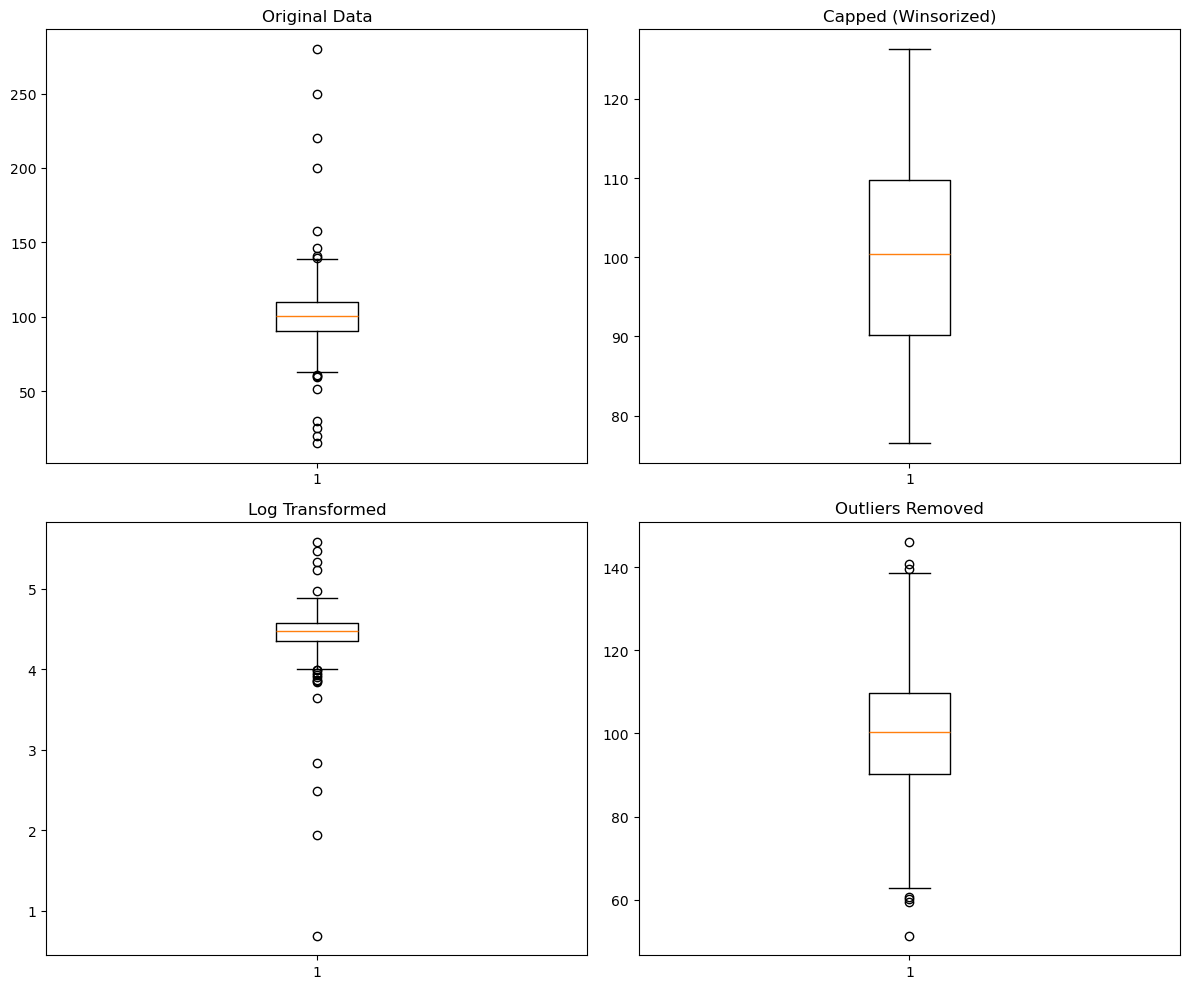

In [3]:
#Handling outliers
# Create a copy for handling
df_handled = df_outliers.copy()
# Option 1: Capping/Winsorizing (replace with boundary values)
cap_value_upper = df_handled['value'].quantile(0.95)
cap_value_lower = df_handled['value'].quantile(0.05)
df_handled['value_capped'] = df_handled['value'].clip(lower=cap_value_lower,
upper=cap_value_upper)
# Option 2: Transformation (reduce impact)
df_handled['value_log'] = np.log1p(df_handled['value']- df_handled['value'].min() + 1)
# Option 3: Remove (if clearly erroneous and few)
df_handled_no_outliers = df_handled[df_handled['z_score'] <= 3].copy()
# Visualize the effect
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Original
axes[0, 0].boxplot(df_handled['value'])
axes[0, 0].set_title('Original Data')
# Capped
axes[0, 1].boxplot(df_handled['value_capped'])
axes[0, 1].set_title('Capped (Winsorized)')
# Log transformed
axes[1, 0].boxplot(df_handled['value_log'])
axes[1, 0].set_title('Log Transformed')
# Removed
axes[1, 1].boxplot(df_handled_no_outliers['value'])
axes[1, 1].set_title('Outliers Removed')
plt.tight_layout()
plt.show()

In [4]:
#Feature Engineering with Complex Dataset
# Create a more complex dataset for feature engineering
from datetime import datetime, timedelta
np.random.seed(42)
n_customers = 500
# Generate customer data
customer_data = {
    'customer_id': range(1000, 1000 + n_customers),
    'age': np.random.randint(18, 70, n_customers),
    'income': np.random.normal(60000, 20000, n_customers).clip(20000, 150000),
    'credit_score': np.random.normal(700, 50, n_customers).clip(300, 850),
    'num_accounts': np.random.randint(1, 10, n_customers),
    'tenure_months': np.random.randint(1, 120, n_customers),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n_customers),
    'signup_date': [datetime.now()- timedelta(days=np.random.randint(30, 1000))
    for _ in range(n_customers)]
}
# Generate transaction data (multiple per customer)
transactions = []
for cust_id in customer_data['customer_id']:
    n_trans = np.random.randint(5, 50)
    for _ in range(n_trans):
        transactions.append({
            'customer_id': cust_id,
            'transaction_date': datetime.now()- timedelta(days=np.random.randint(1, 365)),
            'amount': np.random.exponential(100), # Skewed distribution
            'category': np.random.choice(['retail', 'grocery', 'entertainment', 'travel'])
        })
df_customers = pd.DataFrame(customer_data)
df_transactions = pd.DataFrame(transactions)
print("Customer DataFrame shape:", df_customers.shape)
print("Transactions DataFrame shape:", df_transactions.shape)


Customer DataFrame shape: (500, 8)
Transactions DataFrame shape: (13512, 4)


In [5]:
# Creating interaction features
# Simple interactions
df_features = df_customers.copy()
# Ratio features
df_features['income_per_account'] = df_features['income'] / df_features['num_accounts']
df_features['credit_per_account'] = df_features['credit_score'] / df_features['num_accounts']
# Product features (may capture synergy)
df_features['age_income_interaction'] = df_features['age'] * df_features['income'] / 1000
# Polynomial features (for non-linear relationships)
df_features['age_squared'] = df_features['age'] ** 2
df_features['tenure_squared'] = df_features['tenure_months'] ** 2

In [6]:
# Aggregate transaction data to create features
# Aggregate transaction features per customer
transaction_features = df_transactions.groupby('customer_id').agg({
    'amount': ['count', 'sum', 'mean', 'std', 'max'],
    'transaction_date': lambda x: (datetime.now()- x.max()).days # Recency
}).round(2)
# Flatten column names
transaction_features.columns = ['_'.join(col).strip() for col in transaction_features.columns.values]
transaction_features = transaction_features.rename(columns={
    'amount_count': 'transaction_count',
    'amount_sum': 'total_spent',
    'amount_mean': 'avg_transaction',
    'amount_std': 'transaction_std',
    'amount_max': 'max_transaction',
    'transaction_date_<lambda>': 'days_since_last_transaction'
})
# Merge with customer data
df_features = df_features.merge(transaction_features, on='customer_id', how='left')
# Fill missing for customers with no transactions
df_features = df_features.fillna({
    'transaction_count': 0,
    'total_spent': 0,
    'avg_transaction': 0,
    'transaction_std': 0,
    'max_transaction': 0,
    'days_since_last_transaction': 999 # Large number indicates no transactions
})

In [7]:
# Categorical Feature Engineering
# One-Hot Encoding (for nominal categories)
one_hot = pd.get_dummies(df_features['region'], prefix='region')
df_features = pd.concat([df_features, one_hot], axis=1)
# Label Encoding (for ordinal categories)
# Example: Education level (High School < Bachelor < Master < PhD)
education_order = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
# df_features['education_level_encoded'] = df_features['education'].map(education_order)
# Target Encoding (mean of target per category- careful with leakage!)
# For demonstration, create a synthetic target
df_features['target'] = (
    0.3 * df_features['age'] +
    0.4 * df_features['income'] / 10000 +
    0.2 * df_features['credit_score'] / 100 +
    np.random.randn(n_customers) * 10
)
# Calculate mean target per region (use with cross-validation in practice)
region_target_mean = df_features.groupby('region')['target'].mean()
df_features['region_target_encoded'] = df_features['region'].map(region_target_mean)
# Frequency Encoding (count of each category)
region_freq = df_features['region'].value_counts() / len(df_features)
df_features['region_frequency'] = df_features['region'].map(region_freq)

In [8]:
# Date & Time Feature Engineering
# Extract components from signup_date
df_features['signup_year'] = pd.DatetimeIndex(df_features['signup_date']).year
df_features['signup_month'] = pd.DatetimeIndex(df_features['signup_date']).month
df_features['signup_day'] = pd.DatetimeIndex(df_features['signup_date']).day
df_features['signup_dayofweek'] = pd.DatetimeIndex(df_features['signup_date']).dayofweek
df_features['signup_quarter'] = pd.DatetimeIndex(df_features['signup_date']).quarter
# Cyclical encoding for cyclical features (like month, day of week)
# This preserves the circular nature (e.g., December is close to January)
df_features['month_sin'] = np.sin(2 * np.pi * df_features['signup_month'] / 12)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['signup_month'] / 12)
# Time since event
df_features['years_since_signup'] = df_features['tenure_months'] / 12
# Is weekend? (for dayofweek, 5 and 6 are Saturday/Sunday)
df_features['signup_is_weekend'] = df_features['signup_dayofweek'].isin([5, 6]).astype(int)

In [9]:
# Bining and Discretization
# Age groups
age_bins = [0, 25, 35, 50, 65, 100]
age_labels = ['<25', '25-35', '35-50', '50-65', '65+']
df_features['age_group'] = pd.cut(df_features['age'], bins=age_bins, labels=age_labels)
# Income quantiles (equal-sized groups)
df_features['income_quantile'] = pd.qcut(df_features['income'], q=4,
labels=['Q1', 'Q2', 'Q3', 'Q4'])
# Custom bins with specific boundaries
credit_bins = [300, 580, 670, 740, 800, 850]
credit_labels = ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent']
df_features['credit_tier'] = pd.cut(df_features['credit_score'],
bins=credit_bins, labels=credit_labels)
# One-hot encode the binned features
df_features = pd.get_dummies(df_features, columns=['age_group', 'credit_tier'])

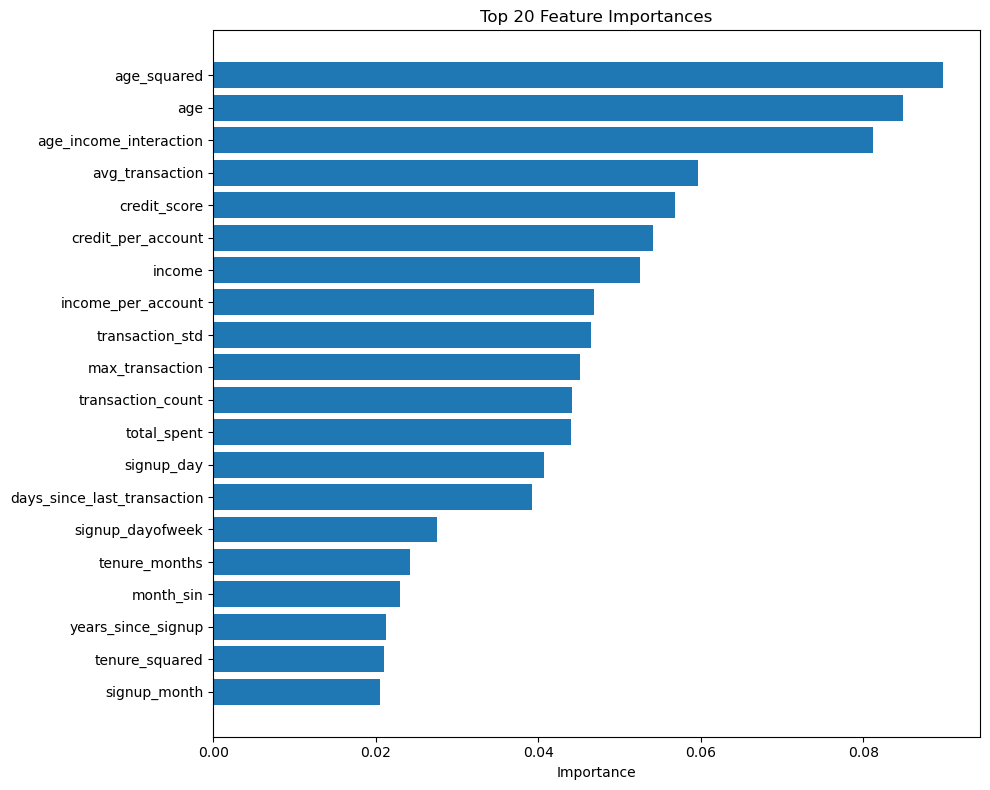

Top 10 Most Important Features:
                   feature  importance
8              age_squared    0.089866
0                      age    0.084893
7   age_income_interaction    0.081190
12         avg_transaction    0.059637
2             credit_score    0.056851
6       credit_per_account    0.054178
1                   income    0.052540
5       income_per_account    0.046891
13         transaction_std    0.046438
14         max_transaction    0.045151


In [10]:
# Feature Important Ananlysis
# After feature engineering, we can check which features matter most
from sklearn.ensemble import RandomForestRegressor
# Prepare data
feature_cols = [col for col in df_features.columns if col not in
['customer_id', 'signup_date', 'region', 'target']]
X=df_features[feature_cols].select_dtypes(include=[np.number]) # Only numeric
y =df_features['target']
# Handle any remaining missing values
X=X.fillna(X.mean())
# Train a quick model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)
# Feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)
# Plot top 20 features
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(20)['feature'],
feature_importance.head(20)['importance'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
print("Top 10 Most Important Features:")
print(feature_importance.head(10))